In [51]:
import numpy as np
import pandas as pd

In [52]:
dataset = pd.read_csv("labeled_data.csv")

In [53]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [54]:
dataset.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [55]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [56]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [57]:
data = dataset[["tweet", "class"]]

In [58]:
data

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,1
24779,"you've gone and broke the wrong heart baby, an...",2
24780,young buck wanna eat!!.. dat nigguh like I ain...,1
24781,youu got wild bitches tellin you lies,1


In [59]:
data.describe()

,class
count,24783.000000
mean,1.110277
std,0.462089
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


In [60]:
data["class"].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

## NLP 

In [61]:
import nltk
import string
import re

In [62]:
#nltk.downloads("stopwords")

In [63]:
stopwords = nltk.corpus.stopwords.words("english")

In [64]:
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [65]:
stopwords = set(stopwords)

In [66]:
stopwords.add("rt")

In [67]:
stemmer = nltk.SnowballStemmer("english")

In [68]:
def clean_data(text):
    text = str(text).lower()
    text = re.sub('https?://\S+|www\.S+', '', text)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' %re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w', '', text)
    # Stemming  |  Tokeniztion   |    Stopwords removal
    text = [stemmer.stem(word) for word in text.split(' ') if word not in stopwords]
    text = " ".join(text)
    return text

In [69]:
data["tweet"] = data["tweet"].apply(clean_data)

C:\Users\vivek\AppData\Local\Temp\ipykernel_28596\1832165696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


In [70]:
data

,tweet,class
0,mayasolov woman shouldnt complain clean hous ...,2
1,boy dat coldtyga dwn bad cuffin dat hoe place,1
2,urkindofbrand dawg ife ever fuck bitch start ...,1
3,cganderson vivabas look like tranni,1
4,shenikarobert shit hear might true might fake...,1
...,...,...
24778,yous muthafin lie ifeask earl coreyemanuel rig...,1
24779,youv gone broke wrong heart babi drove redneck...,2
24780,young buck wanna eat dat nigguh like aint fuck...,1
24781,youu got wild bitch tellin lie,1


In [71]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [72]:
X = np.array(data["tweet"])
y = np.array(data["class"])

In [73]:
cv = CountVectorizer()
X = cv.fit_transform(X)

In [74]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 194326 stored elements and shape (24783, 27804)>

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Build ML

In [76]:
from sklearn.tree import DecisionTreeClassifier

In [77]:
dt = DecisionTreeClassifier()

In [78]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
y_pred = dt.predict(X_test)

In [80]:
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [81]:
y_test

array([1, 1, 2, ..., 1, 1, 1])

In [82]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [83]:
accuracy_score(y_test, y_pred)

0.8655092309573298

In [84]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 163,  272,   30],
       [ 264, 5836,  235],
       [  42,  257, 1080]])

In [85]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_score(y_test, y_pred_rf)

0.8883726616945837

In [86]:
y_pred_rf

array([1, 1, 1, ..., 1, 2, 1])

In [87]:
y_test

array([1, 1, 2, ..., 1, 1, 1])

In [88]:
cm2 = confusion_matrix(y_test, y_pred_rf)
cm2

array([[ 121,  313,   31],
       [ 116, 6064,  155],
       [  12,  286, 1081]])

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

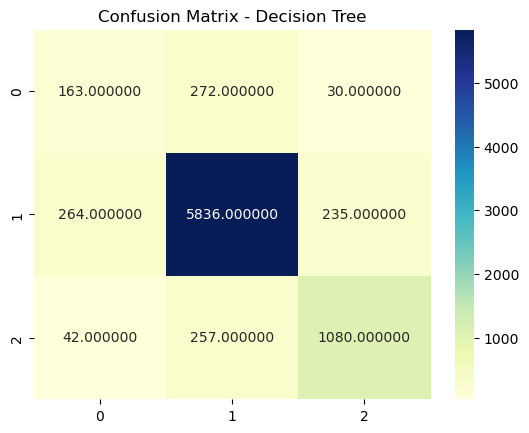

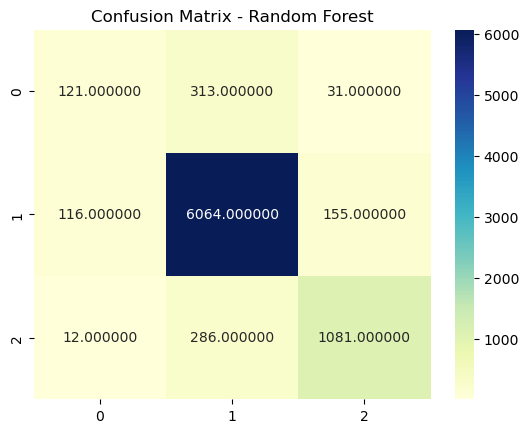

In [92]:
sns.heatmap(cm, annot=True, fmt="f", cmap="YlGnBu")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

sns.heatmap(cm2, annot=True, fmt="f", cmap="YlGnBu")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [93]:
sample = "let's unite and kill all the people who are protesting against the government"
sample = clean_data(sample)

In [94]:
sample

'let unit kill peopl protest govern'

In [95]:
data1 = cv.transform([sample]).toarray()

In [96]:
data1

array([[0, 0, 0, ..., 0, 0, 0]])

In [98]:
dt.predict(data1)
class_labels = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

# Get the numerical prediction
prediction = dt.predict(data1)[0]

# Output the text label
print(class_labels[prediction])

Offensive Language
